# GW spectrum from Graviton Bremsstrahlung and Soft-Graviton Floor

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from math import sqrt, log, exp, log10, pi, atan
import math

plt.rc('text', usetex=True)
plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath, amssymb}"
plt.rc('font', **{'family': 'serif', 'size': 15})

# GW spectrum from $\phi \to \varphi\varphi h$


In [2]:
def f_th(Trh, mphi):
    res = 9*1e9 * (1e13/Trh) * (mphi/1e13)
    return res
    
# Soft Spectrum
def OGWh2_soft(f, Trh,mphi):
    res  = 3.8*1e-18 * (f/1e10)* (Trh/1e13) * (mphi/1e13) 
    return res

# Full Spectrum
def OGWh2(f, Trh,mphi):
    res  = 3.8*1e-18 * (f/1e10)* (Trh/1e13) * (mphi/1e13) * ( 1- 6*(f/f_th(Trh, mphi)) + 8 *(f/f_th(Trh, mphi))**(3/2) -3*(f/f_th(Trh, mphi))**2 )
    return res

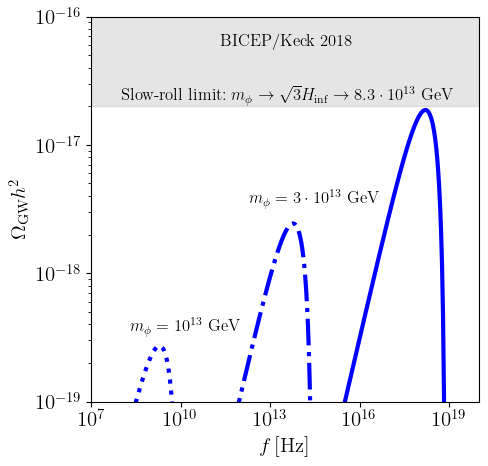

In [19]:
fig, ax = plt.subplots(figsize=(5,5))

x = np.logspace(7, 20, 400)

Mp = 2.4*1e18
HI = 1.0e-5 * Mp
mphi =8.3*1e13
Trh  = 1e5

y1 =  OGWh2(x, Trh,mphi)

x_ann = np.logspace(8, 17.8, 400)
y1_ann = OGWh2_soft(x_ann, Trh,mphi)

plt.plot(x, y1, "b", linewidth=3, label=r'$T_{\text{rh}}=10^5~\text{GeV}$')
# plt.plot(x_ann, y1_ann, "k:", linewidth=4)

HI = 2.0e-5 * Mp
mphi = 3*1e13
Trh  = 1e9

y2 = OGWh2(x, Trh,mphi)

plt.plot(x, y2, "b-.",  linewidth=3, label=r'$T_{\text{rh}}=10^9~\text{GeV}$')


HI = 2.0e-5 * Mp
mphi = 1e13
Trh  = 1e13

y3 = OGWh2(x, Trh,mphi)

plt.plot(x, y3, "b:", linewidth=3,  label=r'$T_{\text{rh}}=10^{13}~\text{GeV}$')

######

# xfill = np.logspace(8, log10(9*1e9), 400)
xfill = np.logspace(8, log10(2*1e9), 400)

# plt.fill_between(xfill, 1e-20,1e-14, color='gray',alpha=0.2)

plt.fill_between(x, 2*1e-17, 1e-15, color='gray',alpha=0.2)

plt.text(2*1e11, 6*1e-17, r'$\text{BICEP/Keck 2018}$', color = "k", size=12,  rotation=0)

plt.text(1*1e8, 2.2*1e-17, r'$\text{Slow-roll limit:}~ m_\phi \to \sqrt{3} H_{\text{inf}} \to 8.3 \cdot 10^{13}~\text{GeV}$', color = "k", size=12, rotation=0)

plt.text(2*1e12, 3.5*1e-18, r'$ m_\phi =3 \cdot 10^{13}~\text{GeV}$', color = "k", size=12, rotation=0)
# plt.text(2*1e15, 2*1e-17, r'$ \to 8.3 \cdot 10^{13}~\text{GeV}$', color = "k", size=12, rotation=0)

plt.text(2*1e8, 3.5*1e-19, r'$ m_\phi =10^{13}~\text{GeV}$', color = "k", size=12, rotation=0)

# plt.text(6.4*1e15, 1.5*1e-19, r'$\text{soft-approximation}$', color = "k", size=15, rotation=76)


plt.xlabel(r'$f\,[\text{Hz}]$')
plt.ylabel(r'$\Omega_{\text{GW}} h^2$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e7, 1e20)
ax.set_ylim(1e-19, 1e-16)
# plt.title(r'$\text{Graviton Floor from Bremsstrahlung}$', fontsize=15)

# ax.legend(loc='upper left', bbox_to_anchor=(0., 0.75), prop={'size': 10})
plt.savefig("./GW_floor.pdf", bbox_inches="tight")
plt.show()

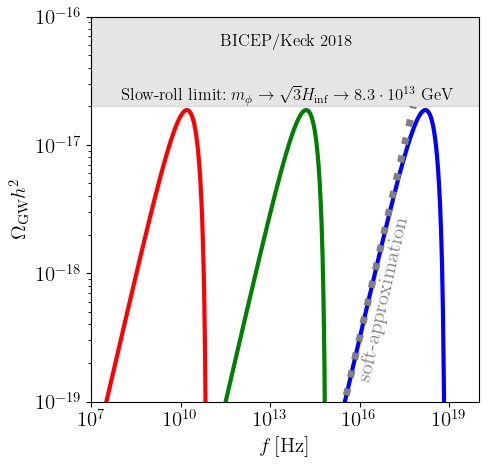

In [18]:
fig, ax = plt.subplots(figsize=(5,5))

x = np.logspace(7, 20, 400)

HI = 1.0e-5 * Mp
mphi =8.3*1e13
Trh  = 1e5

y1 = OGWh2(x, Trh,mphi)

x_ann = np.logspace(8, 17.8, 400)

y1_ann = OGWh2_soft(x_ann, Trh,mphi)

plt.plot(x, y1, "b", linewidth=3, label=r'$T_{\text{rh}}=10^5~\text{GeV}$')
plt.plot(x_ann, y1_ann, "gray",linestyle=':',  linewidth=5)

HI = 2.0e-5 * Mp
mphi =8.3*1e13
Trh  = 1e9

y2 = OGWh2(x, Trh,mphi)

plt.plot(x, y2, "g",  linewidth=3, label=r'$T_{\text{rh}}=10^9~\text{GeV}$')

HI = 2.0e-5 * Mp
mphi =8.3*1e13
Trh  = 1e13

y3 = OGWh2(x, Trh,mphi)

plt.plot(x, y3, "r", linewidth=3,  label=r'$T_{\text{rh}}=10^{13}~\text{GeV}$')


######

xfill = np.logspace(8, log10(2*1e9), 400)

plt.fill_between(x, 2*1e-17, 1e-15, color='gray',alpha=0.2)


plt.text(2*1e11, 6*1e-17, r'$\text{BICEP/Keck 2018} $', color = "k", size=12,  rotation=0)


plt.text(1*1e8, 2.2*1e-17, r'$\text{Slow-roll limit:}~ m_\phi \to \sqrt{3} H_{\text{inf}} \to 8.3 \cdot 10^{13}~\text{GeV}$', color = "k", size=12, rotation=0)
plt.text(7*1e15, 1.5*1e-19, r'$\text{soft-approximation}$', color = "gray", size=15, rotation=77)


plt.xlabel(r'$f\,[\text{Hz}]$')
plt.ylabel(r'$\Omega_{\text{GW}} h^2$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e7, 1e20)
ax.set_ylim(1e-19, 1e-16)
# plt.title(r'$\text{Graviton Floor from Bremsstrahlung}$', fontsize=15)

# ax.legend(loc='upper left', bbox_to_anchor=(0., 0.75), prop={'size': 10})
plt.savefig("./GW_floor2.pdf", bbox_inches="tight")
plt.show()

# GW spectrum from $\phi \to \varphi\varphi\varphi h$

$$
\phi \to \varphi\varphi\varphi h
$$
starting from the exact squared matrix element used in the appendix draft.

The workflow is:

1. implement the exact $1\to 3+h$ kinematics with the recursive factorization
$$
   Q \to k+p_4,\qquad k\to p_2+p_3,
$$
   where $Q=p_1-p_5$ and $s\equiv k^2$;

2. evaluate the exact reduced kernel
  $$
   J(x)=\frac{1}{4\pi(1-x)^2}\int_0^{1-x} d\hat s\,(1-x-\hat s)
   \int_{-1}^{1}dc\int_{-1}^{1}dc_\ast\int_0^{2\pi}d\phi_\ast\,
   \mathcal F(x,y,z,u,v),
   $$
   numerically using Monte-Carlo; $J(x) \to 1$ when $x \to 0$.

3. construct the collision term
  $$
   \mathcal C_{1\to3+h}(x,a)
   =
   \frac{n_\phi(a)\lambda^2}{1536\pi^3 M_P^2}
   \frac{(1-x)\,J(x)}{x^3};
   $$

4. integrate the Boltzmann equation through matter-dominated reheating;

5. redshift the frozen distribution to today and obtain $\Omega_{\rm GW}(f)h^2$.

The hard $3$-body decay width for the interaction
$$
\mathcal L_{\rm int}=\frac{\lambda}{3}\phi\varphi^3
$$
with three identical massless $\varphi$ final states is
$$
\Gamma_{\phi\to 3\varphi}
=
\frac{1}{2m_\phi}\frac{1}{3!}\lambda^2 \Phi_3(m_\phi^2)
=
\frac{\lambda^2\,m_\phi}{3072\pi^3},
\qquad
\Phi_3(m_\phi^2)=\frac{m_\phi^2}{256\pi^3}.
$$

This notebook is fully numerical in the hard region; there is no interpolation ansatz for the matrix element.


In [5]:
from scipy.stats import qmc
from scipy.interpolate import PchipInterpolator
from scipy.integrate import cumulative_trapezoid

plt.rc('text', usetex=True)
plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath, amssymb}"
plt.rc('font', **{'family': 'serif', 'size': 15})


# ---------- constants ----------
M_P = 2.435e18                 # reduced Planck mass [GeV]
g_star = 106.75
gS0 = 3.91
T0 = 2.348e-13                 # CMB temperature today [GeV]
GEV_TO_HZ = 2.417989242e23     # ordinary frequency [Hz] corresponding to 1 GeV
rho_c_over_h2 = 8.098e-47      # critical density divided by h^2 [GeV^4]

# ---------- reheating relations ----------
def gamma_from_trh(Trh, gstar=g_star, MP=M_P):
    pref = math.sqrt(2.0 / math.pi) * (10.0 / gstar) ** 0.25
    return (Trh / pref) ** 2 / MP

def trh_from_gamma(Gamma, gstar=g_star, MP=M_P):
    pref = math.sqrt(2.0 / math.pi) * (10.0 / gstar) ** 0.25
    return pref * math.sqrt(MP * Gamma)

def a_rh_over_a0(Trh, gstarS_rh=g_star):
    return (T0 / Trh) * (gS0 / gstarS_rh) ** (1.0 / 3.0)

def f_threshold_hz(mphi, Trh):
    return 0.5 * mphi * a_rh_over_a0(Trh) * GEV_TO_HZ


def lambda_from_gamma_3body(Gamma, mphi):
    return math.sqrt(3072.0 * math.pi**3 * Gamma / mphi)

def gamma_3body_from_lambda(lam, mphi):
    return lam**2 * mphi / (3072.0 * math.pi**3)

def H_rh_from_gamma(Gamma):
    # Using H(Trh) ≃ 2 Γ / 3
    return 2.0 * Gamma / 3.0



## Exact $1\to 3+h$ kernel

The exact squared matrix element is taken from the appendix draft,
$$
|\mathcal M|^2
=
\lambda^2 \frac{1}{M_P^2}\frac{2}{x^2}\,\mathcal F(x,y,z,u,v),
$$
with
$$
\mathcal F(x,y,z,u,v)=\frac{1}{u\,v\,(u+v-x)}\Big[
u^{2}\big(v(x+1)^{2}-x(x+z)^{2}\big)
+u\Big(v^{2}(x+1)^{2}
-vx\big(3x^{2}+2x(y+z+1)-2yz+4y+4z-3\big)
+2x^{2}(x+z)(x+y+z-1)\Big)
-x\big(x(-v+y+z-1)-vy+x^{2}\big)^{2}
\Big].
$$

The variables $(y,z,u,v)$ are reconstructed from exact Lorentz kinematics with the recursive factorization
$$
Q\to k+p_4,\qquad k\to p_2+p_3,
$$
where $Q=p_1-p_5$ and $s=k^2$.


# Kernal

In [6]:
import numpy as np
from scipy.stats import qmc

def F_exact_stable(x, y, z, u, v, eps=1e-30, x_switch=1e-8):
    """
    Stable evaluation of the exact reduced kernel F(x,y,z,u,v).

    For very small x, evaluate the analytically x^3-factored form to avoid
    catastrophic cancellation in num/den ~ O(x^3)/O(x^3).
    """
    if x < x_switch:
        U = u / x
        V = v / x

        num0 = (
            U*U * (V - z*z)
            + U * (
                V*V
                + V * (2.0*y*z - 4.0*y - 4.0*z + 3.0)
                + 2.0*z * (y + z - 1.0)
            )
            - ((y + z - 1.0) - V*y)**2
        )
        den0 = U * V * (U + V - 1.0)
        den0 = np.where(np.abs(den0) < eps, np.sign(den0 + eps) * eps, den0)
        return num0 / den0

    num = (
        u*u * (v * (x + 1.0)**2 - x * (x + z)**2)
        + u * (
            v*v * (x + 1.0)**2
            - v*x * (3.0*x*x + 2.0*x*(y + z + 1.0) - 2.0*y*z + 4.0*y + 4.0*z - 3.0)
            + 2.0*x*x * (x + z) * (x + y + z - 1.0)
        )
        - x * (x * (-v + y + z - 1.0) - v*y + x*x)**2
    )

    den = u * v * (u + v - x)
    den = np.where(np.abs(den) < eps, np.sign(den + eps) * eps, den)
    return num / den

def F_exact_full(x, y, z, u, v, eps=1e-30):
    num = (
        u*u * (v * (x + 1.0)**2 - x * (x + z)**2)
        + u * (
            v*v * (x + 1.0)**2
            - v*x * (3.0*x*x + 2.0*x*(y + z + 1.0) - 2.0*y*z + 4.0*y + 4.0*z - 3.0)
            + 2.0*x*x * (x + z) * (x + y + z - 1.0)
        )
        - x * (x * (-v + y + z - 1.0) - v*y + x*x)**2
    )
    den = u * v * (u + v - x)
    den = np.where(np.abs(den) < eps, np.sign(den + eps) * eps, den)
    return num / den

def F_exact_softbranch(x, y, z, u, v, eps=1e-30):
    U = u / x
    V = v / x
    num0 = (
        U*U * (V - z*z)
        + U * (
            V*V
            + V * (2.0*y*z - 4.0*y - 4.0*z + 3.0)
            + 2.0*z * (y + z - 1.0)
        )
        - ((y + z - 1.0) - V*y)**2
    )
    den0 = U * V * (U + V - 1.0)
    den0 = np.where(np.abs(den0) < eps, np.sign(den0 + eps) * eps, den0)
    return num0 / den0


def kernel_samples_exact(x, U):
    """
    Samples the exact Appendix C kernel using the corrected kinematics.
    """
    u0, u1, u2, u3 = U.T

    # importance map for \hat s integration:
    # d\hat s (1-x-\hat s)  -> flat in u0
    t   = 1.0 - np.sqrt(1.0 - u0)
    c   = 2.0 * u1 - 1.0
    cs  = 2.0 * u2 - 1.0
    phi = 2.0 * np.pi * u3

    omx = 1.0 - x
    sqQ = np.sqrt(omx)
    shat = t * omx   # this is \hat s

    # Q-rest-frame kinematics
    E2_star = ((omx + shat) + (omx - shat) * cs) / (4.0 * sqQ)
    E3_star = ((omx + shat) - (omx - shat) * cs) / (4.0 * sqQ)

    p2_par = ((omx - shat) + (omx + shat) * cs) / (4.0 * sqQ)
    p3_par = ((omx - shat) - (omx + shat) * cs) / (4.0 * sqQ)

    p_perp = 0.5 * np.sqrt(shat) * np.sqrt(np.maximum(1.0 - cs**2, 0.0))

    sin_theta = np.sqrt(np.maximum(1.0 - c**2, 0.0))
    cos_phi = np.cos(phi)

    p2z_star = p2_par * c - p_perp * sin_theta * cos_phi
    p3z_star = p3_par * c + p_perp * sin_theta * cos_phi

    # graviton in Q-rest-frame
    E5_star = x / (2.0 * sqQ)

    # exact invariants u,v
    u = 2.0 * E5_star * (E2_star - p2z_star)
    v = 2.0 * E5_star * (E3_star - p3z_star)

    # exact Appendix-C.1 formulas for y,z
    y = 0.5 * ((omx + shat) + (omx - shat) * cs) + u
    z = 0.5 * ((omx + shat) - (omx - shat) * cs) + v

    return F_exact_stable(x, y, z, u, v)
    # return F_exact_full(x, y, z, u, v)

def kernel_J(x, U):
    """
    Reduced kernel J(x), defined by

        J(x) = [4 pi (1-x)^2]^{-1}
               ∫ dŝ (1-x-ŝ) dc dc_* dφ  F

    so that

        C(x) = [nphi lambda^2 /(1536 pi^3 M_P^2)]
               * [(1-x) J(x) / x^3].
    """
    vals = kernel_samples_exact(x, U)
    return np.mean(vals)


def build_kernel_grid(n_sobol_pow=15, x_min=1e-10, x_split=1e-2,
                      n_log=80, n_lin=240, x_max=0.9999999, seed=12345):
    engine = qmc.Sobol(d=4, scramble=True, seed=seed)
    U = engine.random_base2(n_sobol_pow)

    x_log = np.logspace(np.log10(x_min), np.log10(x_split), n_log, endpoint=False)
    x_lin = np.linspace(x_split, x_max, n_lin)
    x_grid = np.unique(np.concatenate(([x_min], x_log, x_lin)))

    J_grid = np.array([kernel_J(x, U) for x in x_grid])
    return x_grid, J_grid


# example
x_grid, J_grid = build_kernel_grid()

print(f"x grid size = {len(x_grid)}")
print(f"J(x_min) = {J_grid[0]:.6f}")
print(f"J(0.5)   = {J_grid[np.argmin(np.abs(x_grid-0.5))]:.6f}")
print(f"J(x_max) = {J_grid[-1]:.6e}")

x grid size = 320
J(x_min) = 0.666720
J(0.5)   = 0.167490
J(x_max) = -1.236768e-14


In [7]:
F_exact_stable(1e-4,1,1,1,1)

np.float64(0.9999999800000001)

In [8]:
F_exact_stable(1e-10,0,0,1e-10,1e-10)

np.float64(4.0)

In [9]:
x_test = 1e-10
engine = qmc.Sobol(d=4, scramble=True, seed=12345)
U = engine.random_base2(15)

vals = kernel_samples_exact(x_test, U)
print(np.mean(vals), np.min(vals), np.max(vals))

0.6667201659804765 9.401600378103533e-05 0.9999999987692432


In [10]:
def kernel_samples_one(x, U):
    return np.ones(U.shape[0])

def kernel_J_one(x, U):
    return np.mean(kernel_samples_one(x, U))

engine = qmc.Sobol(d=4, scramble=True, seed=12345)
U = engine.random_base2(15)

print(kernel_J_one(1e-10, U))

1.0


In [11]:
def kernel_samples_t(x, U):
    u0 = U[:,0]
    t = 1.0 - np.sqrt(1.0 - u0)
    return t

def kernel_J_t(x, U):
    return np.mean(kernel_samples_t(x, U))

print(kernel_J_t(1e-10, U))

0.3333333187915395


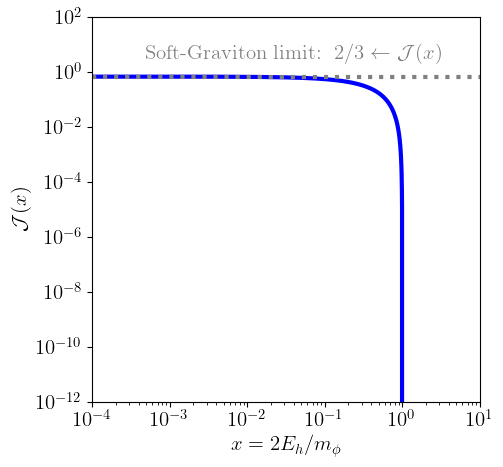

In [21]:
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(x_grid, J_grid,'b' ,lw=3)
ax.axhline(y = 2/3, color = 'gray', linestyle = ':',linewidth=3) 
ax.set_xscale("log")
ax.set_xlabel(r'$x = 2E_h/m_\phi$')
ax.set_ylabel(r'$\mathcal{J}(x)$')
# ax.grid(alpha=0.3)
ax.set_xscale('log')
ax.set_yscale('log')
plt.text(5*1e-4, 3, r'$\text{Soft-Graviton limit:}~~2/3 \leftarrow \mathcal{J}(x)$', color = "gray", size=15, rotation=0)

ax.set_xlim(1e-4, 1e1)
ax.set_ylim(1e-12, 1e2)
# ax.legend(loc='upper left', bbox_to_anchor=(0.03, 1), prop={'size': 15})
plt.savefig("./Jx.pdf", bbox_inches="tight")
plt.show()


## Frozen graviton distribution and present-day spectrum

With the reduced kernel $J(x)$, the collision term is
$$
\mathcal C(x,a)
=
\frac{n_\phi(a)\lambda^2}{1536\pi^3 M_P^2}
\frac{(1-x)\,J(x)}{x^3},
\qquad
x=\frac{2\tilde p_h}{a\,m_\phi}.
$$

Approximating reheating as matter dominated,
$$
H(a)=H_{\rm rh}\left(\frac{a_{\rm rh}}{a}\right)^{3/2},
\qquad
n_\phi(a)=\frac{3M_P^2H(a)^2}{m_\phi},
$$
the frozen graviton distribution at $a_{\rm rh}$ can be written in terms of
$$
z=\frac{2p_h(a_{\rm rh})}{m_\phi}=\frac{f}{f_{\rm th}}
$$
as
$$
f_h(z;a_{\rm rh})
=
\frac{H_{\rm rh}\lambda^2}{512\pi^3m_\phi}\,
z^{-3/2}\,
G(z),
\qquad
G(z)=\int_z^1 dx\,\frac{(1-x)J(x)}{x^{5/2}}.
$$

The present-day spectrum is then
$$
\Omega_{\rm GW}(f)h^2
=
\frac{16\pi^2 f_{\rm nat}^4}{\rho_c/h^2}\,f_h,
\qquad
f_{\rm nat} = \frac{f_{\rm Hz}}{2.417989242\times 10^{23}\,{\rm Hz/GeV}}.
$$


In [13]:
integrand_grid = (1.0 - x_grid) * J_grid / x_grid**2.5
G_grid = -cumulative_trapezoid(integrand_grid[::-1], x_grid[::-1], initial=0.0)[::-1]

J_interp = PchipInterpolator(x_grid, J_grid)
G_interp = PchipInterpolator(x_grid, G_grid)

def f_h_reheating(z, mphi, Trh):
    '''
    Frozen graviton phase-space distribution at a_rh.
    z = f / f_th = 2 p_h(a_rh) / mphi
    '''
    Gamma = gamma_from_trh(Trh)
    lam = lambda_from_gamma_3body(Gamma, mphi)
    Hrh = H_rh_from_gamma(Gamma)

    z = np.asarray(z)
    out = np.zeros_like(z, dtype=float)

    mask = (z > 0.0) & (z < x_grid[-1])
    zz = z[mask]

    pref = Hrh * lam**2 / (512.0 * math.pi**3 * mphi)
    out[mask] = pref * zz**(-1.5) * G_interp(zz)
    return out

def spectrum_omega_h2(f_hz, mphi, Trh):
    '''
    Present-day GW spectrum Ω_GW h^2 at ordinary frequency f_hz [Hz].
    Here f_hz is ordinary frequency, while p = h f is the physical momentum/energy.
    Since GEV_TO_HZ converts GeV -> ordinary Hz, p[GeV] = f_hz / GEV_TO_HZ.
    '''
    fth = f_threshold_hz(mphi, Trh)
    z = np.asarray(f_hz) / fth
    fh = f_h_reheating(z, mphi, Trh)

    p_nat = np.asarray(f_hz) / GEV_TO_HZ   # physical momentum/energy in GeV
    omega_h2 = p_nat**4 * fh / (math.pi**2 * rho_c_over_h2)
    return omega_h2

def shape_function_3body(z):
    z = np.asarray(z)
    out = np.zeros_like(z, dtype=float)
    mask = (z > 0.0) & (z < x_grid[-1])
    out[mask] = z[mask]**(-1.5) * G_interp(z[mask])
    return out


In [14]:

# ---------- benchmark parameters ----------
mphi = 8.3*1e13   # GeV
Trh  = 1.0e10   # GeV

Gamma = gamma_from_trh(Trh)
lam = lambda_from_gamma_3body(Gamma, mphi)
fth = f_threshold_hz(mphi, Trh)

print(f"mphi   = {mphi:.3e} GeV")
print(f"Trh    = {Trh:.3e} GeV")
print(f"Gamma  = {Gamma:.3e} GeV")
print(f"lambda = {lam:.3e} GeV")
print(f"f_th   = {fth:.3e} Hz")


mphi   = 8.300e+13 GeV
Trh    = 1.000e+10 GeV
Gamma  = 2.108e+02 GeV
lambda = 4.918e-04 GeV
f_th   = 7.825e+13 Hz


Peak z = 0.1651
Peak f = 1.2916e+13 Hz
Peak Ω_GW h^2 = 9.0062e-18


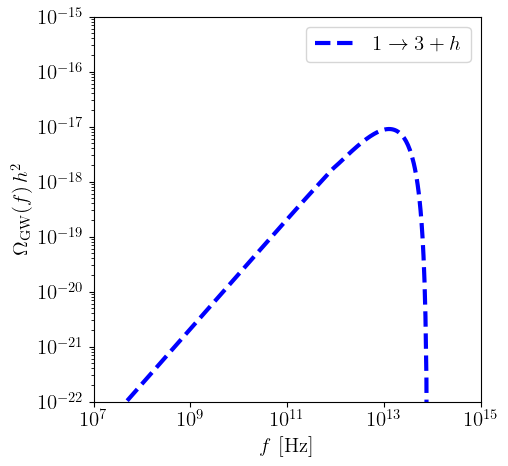

In [15]:
z_plot = np.logspace(-8, np.log10(0.999), 400)
f_plot = fth * z_plot
omega_plot = spectrum_omega_h2(f_plot, mphi, Trh)

peak_idx = np.argmax(omega_plot)
print(f"Peak z = {z_plot[peak_idx]:.4f}")
print(f"Peak f = {f_plot[peak_idx]:.4e} Hz")
print(f"Peak Ω_GW h^2 = {omega_plot[peak_idx]:.4e}")

fig, ax = plt.subplots(figsize=(5,5))
ax.loglog(f_plot, omega_plot,'b--' ,lw=3, label=r"$1\to 3+h$")
ax.set_xlabel(r'$f\ {\rm [Hz]}$')
ax.set_ylabel(r'$\Omega_{\rm GW}(f)\,h^2$')
# ax.grid(alpha=0.3, which="both")
ax.set_xlim(1e7, 1e15)
ax.set_ylim(1e-22, 1e-15)
ax.legend()
plt.show()


# Comparison between $\phi \to \varphi\varphi h$ and  $\phi \to \varphi\varphi \varphi h$

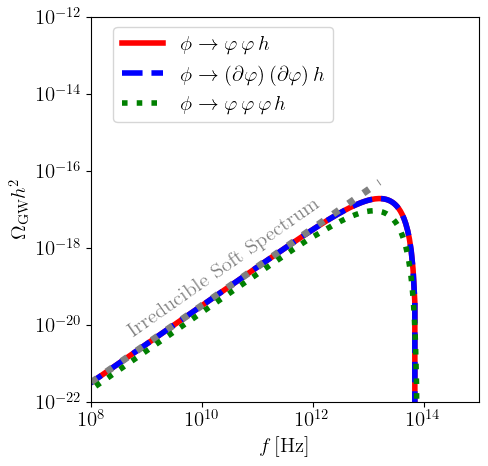

In [16]:
fig, ax = plt.subplots(figsize=(5,5))

x = np.logspace(7, 20, 400)

Mp=2.4*1e18
HI = 1.0e-5 * Mp
mphi =8.3*1e13
Trh  = 1e10

y1 = OGWh2(x, Trh,mphi)

x_ann = np.logspace(8, 13.2, 400)

y1_ann = OGWh2_soft(x_ann, Trh,mphi)

plt.plot(x, y1, "r", linewidth=4, label=r'$\phi \to \varphi\, \varphi \, h$')
plt.plot(x, y1, "b--", linewidth=4, label=r'$\phi \to (\partial \varphi)\, (\partial \varphi)\, h$')

plt.plot(x_ann, y1_ann, "gray",linestyle=':',  linewidth=5)

ax.loglog(f_plot, omega_plot, "g:", linewidth=4, label=r'$\phi \to \varphi\, \varphi\, \varphi\, h$')


# ax.axvline(x = 9*1e9*(mphi/Trh), ymin=0.01,ymax=0.5, color = 'k', linestyle = ':',linewidth=3) 
# 
plt.text(4*1e8, 5*1e-21, r'$\text{Irreducible Soft Spectrum}$', color = "gray", size=15, rotation=35)

plt.xlabel(r'$f\,[\text{Hz}]$')
plt.ylabel(r'$\Omega_{\text{GW}} h^2$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e8, 1e15)
ax.set_ylim(1e-22, 1e-12)
# plt.title(r'$\text{Graviton Floor from Bremsstrahlung}$', fontsize=15)

ax.legend(loc='upper left', bbox_to_anchor=(0.03, 1), prop={'size': 15})
plt.savefig("./2body_3body.pdf", bbox_inches="tight")
plt.show()

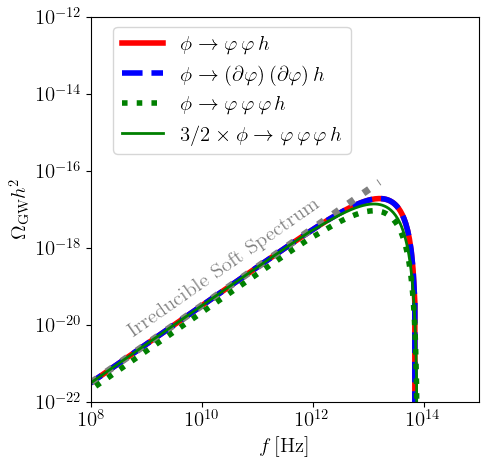

In [17]:
fig, ax = plt.subplots(figsize=(5,5))

x = np.logspace(7, 20, 400)

Mp=2.4*1e18
HI = 1.0e-5 * Mp
mphi =8.3*1e13
Trh  = 1e10

y1 = OGWh2(x, Trh,mphi)

x_ann = np.logspace(8, 13.2, 400)

y1_ann = OGWh2_soft(x_ann, Trh,mphi)

plt.plot(x, y1, "r", linewidth=4, label=r'$\phi \to \varphi\, \varphi \, h$')
plt.plot(x, y1, "b--", linewidth=4, label=r'$\phi \to (\partial \varphi)\, (\partial \varphi)\, h$')

plt.plot(x_ann, y1_ann, "gray",linestyle=':',  linewidth=5)

ax.loglog(f_plot, omega_plot, "g:", linewidth=4, label=r'$\phi \to \varphi\, \varphi\, \varphi\, h$')

ax.loglog(f_plot, 3/2*omega_plot, "g", linewidth=2, label=r'$3/2\times \phi \to \varphi\, \varphi\, \varphi\, h$')

# ax.axvline(x = 9*1e9*(mphi/Trh), ymin=0.01,ymax=0.5, color = 'k', linestyle = ':',linewidth=3) 
# 
plt.text(4*1e8, 5*1e-21, r'$\text{Irreducible Soft Spectrum}$', color = "gray", size=15, rotation=35)

plt.xlabel(r'$f\,[\text{Hz}]$')
plt.ylabel(r'$\Omega_{\text{GW}} h^2$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e8, 1e15)
ax.set_ylim(1e-22, 1e-12)
# plt.title(r'$\text{Graviton Floor from Bremsstrahlung}$', fontsize=15)

ax.legend(loc='upper left', bbox_to_anchor=(0.03, 1), prop={'size': 15})
# plt.savefig("./2body_3body.pdf", bbox_inches="tight")
plt.show()